In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [80]:
df = pd.read_csv('dataset_mood_smartphone.csv')


In [81]:
print(df.shape)          
print(df.info())         
print(df.head())

(376912, 5)
<class 'pandas.DataFrame'>
RangeIndex: 376912 entries, 0 to 376911
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   row_number  376912 non-null  int64  
 1   id          376912 non-null  str    
 2   time        376912 non-null  str    
 3   variable    376912 non-null  str    
 4   value       376710 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 14.4 MB
None
   row_number       id                     time variable  value
0           1  AS14.01  2014-02-26 13:00:00.000     mood    6.0
1           2  AS14.01  2014-02-26 15:00:00.000     mood    6.0
2           3  AS14.01  2014-02-26 18:00:00.000     mood    6.0
3           4  AS14.01  2014-02-26 21:00:00.000     mood    7.0
4           5  AS14.01  2014-02-27 09:00:00.000     mood    6.0


Check for incorrect values based on domain constraints

In [82]:
valid_ranges = {
    'mood': (1, 10),
    'circumplex.arousal': (-2, 2),
    'circumplex.valence': (-2, 2),
    'activity': (0, 1),
    'screen': (0, None),

    'call': (0, 1),
    'sms': (0, 1),

    'appCat.builtin': (0, None),
    'appCat.communication': (0, None),
    'appCat.entertainment': (0, None),
    'appCat.finance': (0, None),
    'appCat.game': (0, None),
    'appCat.office': (0, None),
    'appCat.other': (0, None),
    'appCat.social': (0, None),
    'appCat.travel': (0, None),
    'appCat.unknown': (0, None),
    'appCat.utilities': (0, None),
    'appCat.weather': (0, None),
}

In [83]:
for var, (min_val, max_val) in valid_ranges.items():
    var_df = df[df['variable'] == var]

    # Apply conditions
    if max_val is None:
        invalid = var_df[var_df['value'] < min_val]
    else:
        invalid = var_df[(var_df['value'] < min_val) | (var_df['value'] > max_val)]

    # Print results
    if len(invalid) > 0:
        print(f"\nIncorrect values for variable: {var}")
        print(invalid)


Incorrect values for variable: appCat.builtin
        row_number       id                     time        variable  \
150040      151512  AS14.02  2014-03-16 15:46:43.769  appCat.builtin   
159972      622771  AS14.07  2014-04-30 14:18:06.200  appCat.builtin   
162154      754571  AS14.12  2014-04-02 16:42:16.523  appCat.builtin   

            value  
150040    -44.689  
159972 -82798.871  
162154     -1.218  

Incorrect values for variable: appCat.entertainment
        row_number       id                     time              variable  \
309805      484694  AS14.02  2014-03-26 21:18:45.144  appCat.entertainment   

        value  
309805 -0.011  


In [84]:
# count incorrect values per variable
for var, (min_val, max_val) in valid_ranges.items():
    var_df = df[df['variable'] == var]

    if max_val is None:
        invalid = var_df[var_df['value'] < min_val]
    else:
        invalid = var_df[(var_df['value'] < min_val) | (var_df['value'] > max_val)]

    print(f"{var}: {len(invalid)} invalid values")

mood: 0 invalid values
circumplex.arousal: 0 invalid values
circumplex.valence: 0 invalid values
activity: 0 invalid values
screen: 0 invalid values
call: 0 invalid values
sms: 0 invalid values
appCat.builtin: 3 invalid values
appCat.communication: 0 invalid values
appCat.entertainment: 1 invalid values
appCat.finance: 0 invalid values
appCat.game: 0 invalid values
appCat.office: 0 invalid values
appCat.other: 0 invalid values
appCat.social: 0 invalid values
appCat.travel: 0 invalid values
appCat.unknown: 0 invalid values
appCat.utilities: 0 invalid values
appCat.weather: 0 invalid values


In [85]:
# delete invalid values
# Delete rows with invalid negative values for duration-based app variables
duration_vars = [
    'appCat.builtin',
    'appCat.communication',
    'appCat.entertainment',
    'appCat.finance',
    'appCat.game',
    'appCat.office',
    'appCat.other',
    'appCat.social',
    'appCat.travel',
    'appCat.unknown',
    'appCat.utilities',
    'appCat.weather',
    'screen'
]

mask_invalid_duration = (
    df['variable'].isin(duration_vars) &
    (df['value'] < 0)
)

print("Rows to delete:", mask_invalid_duration.sum())

df_no_invalid = df.loc[~mask_invalid_duration].copy()

print("New shape:", df_no_invalid.shape)

df_no_invalid.to_csv("data1B/dataset_invalid_deleted.csv", index=False)

Rows to delete: 4
New shape: (376908, 5)


In [86]:
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!C

Check if screentime of single app, isn't more than total screentime

In [87]:
# import pandas as pd

# # Make sure time is datetime
# df_no_invalid['time'] = pd.to_datetime(df_no_invalid['time'])

# # Create working copy
# df_check = df_no_invalid.copy()

# # Extract date
# df_check['date'] = df_check['time'].dt.date

# # Define app variables
# app_vars = [
#     'appCat.builtin',
#     'appCat.communication',
#     'appCat.entertainment',
#     'appCat.finance',
#     'appCat.game',
#     'appCat.office',
#     'appCat.other',
#     'appCat.social',
#     'appCat.travel',
#     'appCat.unknown',
#     'appCat.utilities',
#     'appCat.weather'
# ]

# # -------------------------
# # Step 1: Compute daily screen time per user
# # -------------------------
# daily_screen = (
#     df_check[df_check['variable'] == 'screen']
#     .groupby(['id', 'date'], as_index=False)['value']
#     .sum()
#     .rename(columns={'value': 'daily_screen_time'})
# )

# # -------------------------
# # Step 2: Keep only app entries
# # -------------------------
# app_data = df_check[df_check['variable'].isin(app_vars)].copy()

# # -------------------------
# # Step 3: Merge with daily screen time
# # -------------------------
# app_data = pd.merge(
#     app_data,
#     daily_screen,
#     on=['id', 'date'],
#     how='left'
# )

# # -------------------------
# # Step 4: Flag impossible cases
# # -------------------------
# app_data['app_gt_screen'] = (
#     app_data['value'] > app_data['daily_screen_time']
# )

# # -------------------------
# # Step 5: Extract suspicious rows
# # -------------------------
# impossible_app_usage = app_data[app_data['app_gt_screen']].copy()

# # Sort by severity
# impossible_app_usage['difference'] = (
#     impossible_app_usage['value'] - impossible_app_usage['daily_screen_time']
# )

# impossible_app_usage = impossible_app_usage.sort_values(
#     'difference',
#     ascending=False
# )

# # -------------------------
# # Output
# # -------------------------
# print("Number of impossible app usage rows:", len(impossible_app_usage))
# print(impossible_app_usage.head(20))

# # Save to CSV
# impossible_app_usage.to_csv("single_app_gt_screen_time.csv", index=False)

# print("Saved to: single_app_gt_screen_time.csv")

In [88]:
# import pandas as pd

# # Make sure time is datetime
# df_no_invalid['time'] = pd.to_datetime(df_no_invalid['time'])

# # Create working copy
# df_check = df_no_invalid.copy()

# # Extract year-month (e.g. 2014-03)
# df_check['year_month'] = df_check['time'].dt.to_period('M')

# # Define app variables
# app_vars = [
#     'appCat.builtin',
#     'appCat.communication',
#     'appCat.entertainment',
#     'appCat.finance',
#     'appCat.game',
#     'appCat.office',
#     'appCat.other',
#     'appCat.social',
#     'appCat.travel',
#     'appCat.unknown',
#     'appCat.utilities',
#     'appCat.weather'
# ]

# # -------------------------
# # Total screen time per user per month
# # -------------------------
# monthly_screen = (
#     df_check[df_check['variable'] == 'screen']
#     .groupby(['id', 'year_month'], as_index=False)['value']
#     .sum()
#     .rename(columns={'value': 'monthly_screen_time'})
# )

# # -------------------------
# # Total app usage per user per month
# # -------------------------
# monthly_app = (
#     df_check[df_check['variable'].isin(app_vars)]
#     .groupby(['id', 'year_month'], as_index=False)['value']
#     .sum()
#     .rename(columns={'value': 'monthly_app_usage'})
# )

# # -------------------------
# # Merge both
# # -------------------------
# monthly_overview = pd.merge(
#     monthly_screen,
#     monthly_app,
#     on=['id', 'year_month'],
#     how='outer'
# ).fillna(0)

# # -------------------------
# # Add ratio (very useful!)
# # -------------------------
# monthly_overview['app_to_screen_ratio'] = (
#     monthly_overview['monthly_app_usage'] /
#     monthly_overview['monthly_screen_time']
# )

# # -------------------------
# # Sort for inspection
# # -------------------------
# monthly_overview = monthly_overview.sort_values(
#     'app_to_screen_ratio',
#     ascending=False
# )

# # -------------------------
# # Output
# # -------------------------
# print(monthly_overview.head(20))

# # Save to CSV
# monthly_overview.to_csv("monthly_usage_overview.csv", index=False)

# print("Saved to: monthly_usage_overview.csv")

In [89]:
# # -------------------------
# # Step 1: App breakdown per user per month
# # -------------------------
# monthly_app_breakdown = (
#     df_check[df_check['variable'].isin(app_vars)]
#     .groupby(['id', 'year_month', 'variable'])['value']
#     .sum()
#     .reset_index()
# )

# # -------------------------
# # Step 2: Total screen time per user per month
# # -------------------------
# monthly_screen = (
#     df_check[df_check['variable'] == 'screen']
#     .groupby(['id', 'year_month'])['value']
#     .sum()
#     .reset_index()
#     .rename(columns={'value': 'monthly_screen_time'})
# )

# # -------------------------
# # Step 3: Merge screen time into app breakdown
# # -------------------------
# monthly_app_breakdown = pd.merge(
#     monthly_app_breakdown,
#     monthly_screen,
#     on=['id', 'year_month'],
#     how='left'
# )

# # -------------------------
# # Optional: ratio per app category
# # -------------------------
# monthly_app_breakdown['app_to_screen_ratio'] = (
#     monthly_app_breakdown['value'] /
#     monthly_app_breakdown['monthly_screen_time']
# )

# # -------------------------
# # Output
# # -------------------------
# print(monthly_app_breakdown.head(20))

# # Save to CSV
# monthly_app_breakdown.to_csv("monthly_app_breakdown_with_screen.csv", index=False)

# print("Saved to: monthly_app_breakdown_with_screen.csv")

In [90]:
# # -------------------------
# # Filter rows where single app usage > total screen time
# # -------------------------
# impossible_monthly_app = monthly_app_breakdown[
#     monthly_app_breakdown['value'] > monthly_app_breakdown['monthly_screen_time']
# ].copy()

# # Optional: sort by how extreme it is
# impossible_monthly_app['difference'] = (
#     impossible_monthly_app['value'] - impossible_monthly_app['monthly_screen_time']
# )

# impossible_monthly_app = impossible_monthly_app.sort_values(
#     'difference',
#     ascending=False
# )

# # -------------------------
# # Output
# # -------------------------
# print("Number of impossible cases:", len(impossible_monthly_app))
# print(impossible_monthly_app.head(20))

# # Save to CSV
# impossible_monthly_app.to_csv("monthly_single_app_gt_screen.csv", index=False)

# print("Saved to: monthly_single_app_gt_screen.csv")

In [91]:
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


Check if data is skew

In [92]:
# List of continuous variables (same as before)
continuous_vars = [
    'mood',
    'circumplex.arousal',
    'circumplex.valence',
    'activity',
    'screen',
    'appCat.builtin',
    'appCat.communication',
    'appCat.entertainment',
    'appCat.finance',
    'appCat.game',
    'appCat.office',
    'appCat.other',
    'appCat.social',
    'appCat.travel',
    'appCat.unknown',
    'appCat.utilities',
    'appCat.weather'
]

# Store results
skew_results = []

for var in continuous_vars:
    var_df = df_no_invalid[df_no_invalid['variable'] == var]
    
    if len(var_df) > 0:
        skewness = var_df['value'].skew()
        mean = var_df['value'].mean()
        median = var_df['value'].median()
        
        skew_results.append({
            'variable': var,
            'skewness': skewness,
            'mean': mean,
            'median': median
        })

# Convert to DataFrame
skew_df = pd.DataFrame(skew_results)

# Sort by skewness
skew_df = skew_df.sort_values(by='skewness', ascending=False)

print(skew_df)

                variable   skewness        mean     median
12         appCat.social  80.217236   72.401906  28.466000
7   appCat.entertainment  78.065724   37.577866   3.391500
10         appCat.office  68.676169   22.578892   3.106000
5         appCat.builtin  67.228994   19.446411   4.038000
13         appCat.travel  34.013507   45.730850  18.144000
6   appCat.communication  29.352378   43.343792  16.225500
11          appCat.other  21.324189   25.810839  10.028000
15      appCat.utilities  18.114170   18.537552   8.030000
4                 screen  15.672235   75.335206  20.044500
14        appCat.unknown   9.930625   45.553006  17.190000
9            appCat.game   9.690750  128.391615  43.168000
16        appCat.weather   8.947835   20.148714  15.117000
8         appCat.finance   4.236486   21.755251   8.026000
3               activity   2.090476    0.115958   0.021739
1     circumplex.arousal  -0.076296   -0.098624   0.000000
0                   mood  -0.833353    6.992555   7.0000

In [93]:
def classify_skew(x):
    if x > 1:
        return "highly right-skewed"
    elif x > 0.5:
        return "moderately right-skewed"
    elif x < -1:
        return "highly left-skewed"
    elif x < -0.5:
        return "moderately left-skewed"
    else:
        return "approximately symmetric"

skew_df['skew_type'] = skew_df['skewness'].apply(classify_skew)

print(skew_df)

                variable   skewness        mean     median  \
12         appCat.social  80.217236   72.401906  28.466000   
7   appCat.entertainment  78.065724   37.577866   3.391500   
10         appCat.office  68.676169   22.578892   3.106000   
5         appCat.builtin  67.228994   19.446411   4.038000   
13         appCat.travel  34.013507   45.730850  18.144000   
6   appCat.communication  29.352378   43.343792  16.225500   
11          appCat.other  21.324189   25.810839  10.028000   
15      appCat.utilities  18.114170   18.537552   8.030000   
4                 screen  15.672235   75.335206  20.044500   
14        appCat.unknown   9.930625   45.553006  17.190000   
9            appCat.game   9.690750  128.391615  43.168000   
16        appCat.weather   8.947835   20.148714  15.117000   
8         appCat.finance   4.236486   21.755251   8.026000   
3               activity   2.090476    0.115958   0.021739   
1     circumplex.arousal  -0.076296   -0.098624   0.000000   
0       

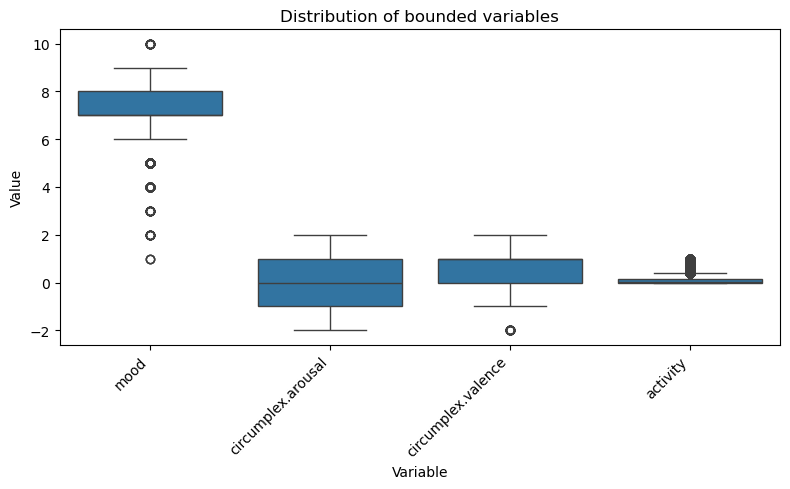

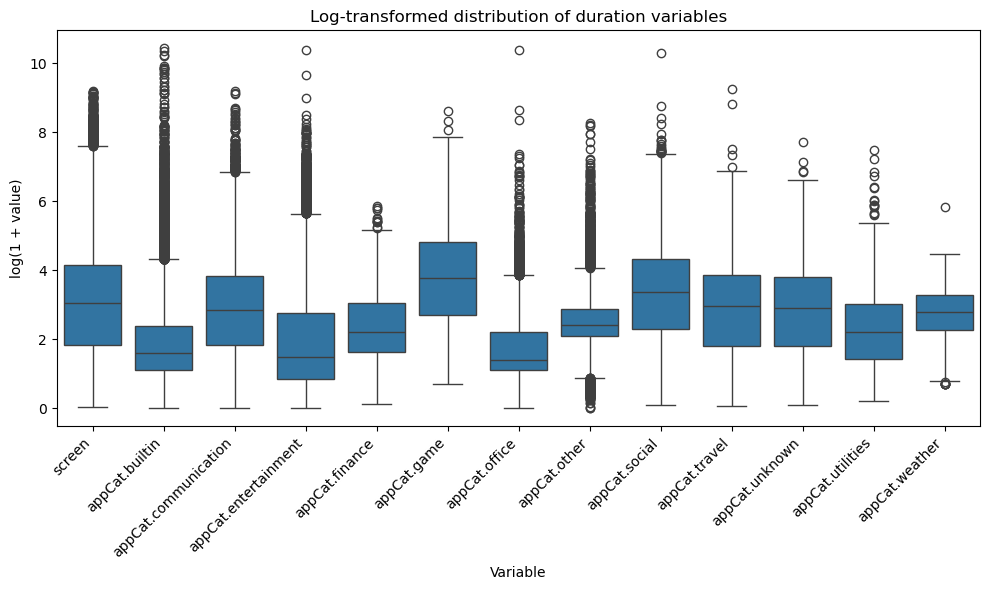

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Variable groups
# -----------------------------
bounded_vars = [
    'mood',
    'circumplex.arousal',
    'circumplex.valence',
    'activity'
]

duration_vars = [
    'screen',
    'appCat.builtin',
    'appCat.communication',
    'appCat.entertainment',
    'appCat.finance',
    'appCat.game',
    'appCat.office',
    'appCat.other',
    'appCat.social',
    'appCat.travel',
    'appCat.unknown',
    'appCat.utilities',
    'appCat.weather'
]

# -----------------------------
# 1) Boxplot for bounded variables
# -----------------------------
bounded_df = df_no_invalid[df_no_invalid['variable'].isin(bounded_vars)].copy()

plt.figure(figsize=(8, 5))
sns.boxplot(data=bounded_df, x='variable', y='value')
plt.title('Distribution of bounded variables')
plt.xlabel('Variable')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Log-boxplot for duration variables
# -----------------------------
duration_df = df_no_invalid[df_no_invalid['variable'].isin(duration_vars)].copy()

# Keep only non-negative values for log transform
duration_df = duration_df[duration_df['value'] >= 0].copy()
duration_df['log_value'] = np.log1p(duration_df['value'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=duration_df, x='variable', y='log_value')
plt.title('Log-transformed distribution of duration variables')
plt.xlabel('Variable')
plt.ylabel('log(1 + value)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Outliers per user

In [95]:
# List of variables where IQR makes sense (continuous variables)
continuous_vars = [
    'mood',
    'circumplex.arousal',
    'circumplex.valence',
    'activity',
    'screen',
    'appCat.builtin',
    'appCat.communication',
    'appCat.entertainment',
    'appCat.finance',
    'appCat.game',
    'appCat.office',
    'appCat.other',
    'appCat.social',
    'appCat.travel',
    'appCat.unknown',
    'appCat.utilities',
    'appCat.weather'
]

outliers_list = []

# Loop over each variable
for var in continuous_vars:
    var_df = df_no_invalid[df_no_invalid['variable'] == var]

    # Group per user
    for user_id, group in var_df.groupby('id'):
        if len(group) < 5:
            continue  # skip small groups

        Q1 = group['value'].quantile(0.25)
        Q3 = group['value'].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = group[
            (group['value'] < lower_bound) |
            (group['value'] > upper_bound)
        ]

        outliers_list.append(outliers)

# Combine all outliers
outliers_df = pd.concat(outliers_list)

print("Total outliers found:", len(outliers_df))
print(outliers_df.head())

outliers_df.to_csv("data1B/outliers.csv", index=False)


Total outliers found: 37818
    row_number       id                     time variable  value
16          17  AS14.01  2014-03-22 21:00:00.000     mood    5.0
25          26  AS14.01  2014-03-24 18:00:00.000     mood    5.0
41          42  AS14.01  2014-03-28 10:00:00.000     mood    5.0
63          64  AS14.01  2014-04-01 17:00:00.000     mood    5.0
64          65  AS14.01  2014-04-01 21:00:00.000     mood    5.0


rolling outlier method thingie

In [96]:
# Make sure time is datetime
df_no_invalid['time'] = pd.to_datetime(df_no_invalid['time'])

# Sort by user, variable, and time
df_no_invalid = df_no_invalid.sort_values(['id', 'variable', 'time']).copy()

# Parameters
window_size = 10       # number of recent observations
threshold = 3      # lower = more sensitive

anomalies_list = []

# Only use numeric / continuous variables for rolling anomaly detection
continuous_vars = [
    'mood',
    'circumplex.arousal',
    'circumplex.valence',
    'activity',
    'screen',
    'appCat.builtin',
    'appCat.communication',
    'appCat.entertainment',
    'appCat.finance',
    'appCat.game',
    'appCat.office',
    'appCat.other',
    'appCat.social',
    'appCat.travel',
    'appCat.unknown',
    'appCat.utilities',
    'appCat.weather'
]

for var in continuous_vars:
    var_df = df_no_invalid[df_no_invalid['variable'] == var].copy()

    for user_id, group in var_df.groupby('id'):
        group = group.sort_values('time').copy()

        # Skip groups that are too small
        if len(group) < 2:
            continue

        group['rolling_mean'] = group['value'].shift(1).rolling(window=window_size, min_periods=2).mean()
        group['rolling_std'] = group['value'].shift(1).rolling(window=window_size, min_periods=2).std()

        # Replace zero std with tiny number to avoid division by zero
        group = group[group['rolling_std'] > 1e-3]

        # Compute deviation score
        group['deviation'] = (
            (group['value'] - group['rolling_mean']).abs() / group['rolling_std']
        )

        # Remove rows where rolling stats are still NaN
        group = group.dropna(subset=['rolling_mean', 'rolling_std', 'deviation'])

        # Flag anomalies
        group['is_anomaly'] = group['deviation'] > threshold

        anomalies = group[group['is_anomaly']].copy()

        if not anomalies.empty:
            anomalies_list.append(anomalies)

# Combine results safely
if anomalies_list:
    rolling_anomalies_df = pd.concat(anomalies_list, ignore_index=False)
else:
    rolling_anomalies_df = pd.DataFrame(columns=[
        'row_number', 'id', 'time', 'variable', 'value',
        'rolling_mean', 'rolling_std', 'deviation', 'is_anomaly'
    ])

print("Total rolling anomalies found:", len(rolling_anomalies_df))
print(len(rolling_anomalies_df) / len(df_no_invalid) * 100)

print(rolling_anomalies_df.head(20))

Total rolling anomalies found: 24185
6.4166852388381255
     row_number       id                time variable  value  rolling_mean  \
41           42  AS14.01 2014-03-28 10:00:00     mood    5.0           6.8   
63           64  AS14.01 2014-04-01 17:00:00     mood    5.0           7.2   
80           81  AS14.01 2014-04-05 12:00:00     mood    8.0           6.2   
96           97  AS14.01 2014-04-08 20:00:00     mood    5.0           6.7   
129         130  AS14.01 2014-04-15 21:00:00     mood    4.0           7.2   
174         175  AS14.01 2014-04-25 09:00:00     mood    6.0           7.6   
193         194  AS14.01 2014-04-29 09:00:00     mood    6.0           7.6   
238         239  AS14.02 2014-03-19 23:00:00     mood    5.0           7.7   
259         260  AS14.02 2014-03-24 22:00:00     mood    8.0           6.1   
299         300  AS14.02 2014-04-02 18:00:00     mood    5.0           7.5   
348         349  AS14.02 2014-04-14 19:00:00     mood   10.0           6.9   
369     

Overlap

In [97]:
# Convert indices to sets
iqr_indices = set(outliers_df.index)
rolling_indices = set(rolling_anomalies_df.index)

# Overlap
common = iqr_indices.intersection(rolling_indices)

print("IQR outliers:", len(iqr_indices))
print("Rolling anomalies:", len(rolling_indices))
print("Overlap:", len(common))

# Percentage overlap
if len(iqr_indices) > 0:
    print("Overlap (% of IQR):", len(common) / len(iqr_indices))

IQR outliers: 37818
Rolling anomalies: 24185
Overlap: 16672
Overlap (% of IQR): 0.4408482733090063


In [98]:
# save to file

# Convert set to list (needed for indexing)
common_list = list(common)

# Select overlap rows from original dataset
overlap_df = df_no_invalid.loc[common_list].copy()

# Optional: sort nicely
overlap_df = overlap_df.sort_values(['id', 'variable', 'time'])

# Save to CSV
overlap_df.to_csv("data1B/overlap_outliers.csv", index=False)

print("Overlap outliers saved:", len(overlap_df))

overlap_with_info = overlap_df.merge(
    rolling_anomalies_df[['deviation']],
    left_index=True,
    right_index=True,
    how='left'
)

overlap_with_info.to_csv("data1B/overlap_outliers_with_scores.csv", index=False)

Overlap outliers saved: 16672


Inspect outliers

In [99]:
overlap_df.describe()

,row_number,time,value
count,1.667200e+04,16672,16672.000000
mean,4.712541e+05,2014-04-16 06:00:44.613084,372.491016
min,4.200000e+01,2014-03-13 16:19:59.157000,-2.000000
25%,1.038348e+05,2014-04-03 12:41:40.047000,55.183000
50%,2.470400e+05,2014-04-15 23:06:33.155500,168.179000
75%,5.375922e+05,2014-04-27 21:53:40.686750,364.356000
max,3.656910e+06,2014-06-08 11:03:34.453000,33960.246000
std,5.391654e+05,NaN,1037.552004


In [100]:
overlap_df.groupby('variable')['value'].describe()

,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
activity,868.0,0.501749,0.203923,0.083333,0.347734,0.486645,0.614102,1.000
appCat.builtin,4424.0,243.395717,1400.021003,10.458000,30.055500,51.191000,106.726750,33960.246
appCat.communication,3189.0,320.109960,509.343995,45.633000,130.618000,196.470000,325.928000,9830.777
appCat.entertainment,1390.0,312.051031,1081.054273,9.036000,42.947000,80.061000,306.002000,32148.677
appCat.finance,51.0,118.012412,77.194331,19.179000,55.918500,104.450000,164.134000,355.513
appCat.game,21.0,846.664714,1137.506641,176.202000,295.094000,462.792000,978.279000,5491.793
appCat.office,325.0,231.068991,1860.067325,10.904000,18.746000,31.209000,74.290000,32708.818
appCat.other,349.0,236.002771,466.429897,2.008000,45.136000,88.579000,220.850000,3892.038
appCat.social,878.0,483.816215,1090.363612,50.862000,212.967000,330.950000,545.559250,30000.906


In [101]:
overlap_df.sort_values('value', ascending=False).head(20)

,row_number,id,time,variable,value
172955,1011941,AS14.14,2014-04-08 23:34:57.855,appCat.builtin,33960.246
340707,1356866,AS14.29,2014-04-19 23:15:02.463,appCat.office,32708.818
324731,534116,AS14.09,2014-03-23 23:13:26.411,appCat.entertainment,32148.677
204569,166419,AS14.27,2014-04-20 23:13:11.269,appCat.builtin,31729.818
360243,1752397,AS14.19,2014-04-21 01:10:07.884,appCat.social,30000.906
165330,805231,AS14.12,2014-04-19 02:10:37.487,appCat.builtin,28163.993
163298,773471,AS14.12,2014-04-09 02:42:21.210,appCat.builtin,27160.374
196457,152701,AS14.26,2014-04-16 23:48:21.302,appCat.builtin,20556.690
154152,250011,AS14.03,2014-04-03 02:13:51.013,appCat.builtin,19452.963
154277,2637110,AS14.03,2014-04-12 05:32:37.091,appCat.builtin,19372.478


In [102]:
overlap_df.sort_values('value').head(20)

,row_number,id,time,variable,value
15264,15265,AS14.25,2014-04-29 15:00:00,circumplex.valence,-2.0
11660,11661,AS14.02,2014-04-22 23:00:00,circumplex.valence,-2.0
8605,8606,AS14.17,2014-04-11 09:00:00,circumplex.arousal,-2.0
16799,16800,AS14.33,2014-04-30 10:00:00,circumplex.valence,-2.0
15902,15903,AS14.28,2014-04-16 17:00:00,circumplex.valence,-2.0
16818,16819,AS14.33,2014-05-07 15:00:00,circumplex.valence,-2.0
8700,8701,AS14.17,2014-05-03 09:00:00,circumplex.arousal,-2.0
10819,10820,AS14.31,2014-04-13 09:00:00,circumplex.arousal,-2.0
11920,11921,AS14.05,2014-03-22 12:00:00,circumplex.valence,-2.0
15058,15059,AS14.24,2014-05-14 15:00:00,circumplex.valence,-2.0


In [103]:
# Example thresholds (adjust if needed)
extreme = overlap_with_info[overlap_with_info['value'] > overlap_with_info['value'].quantile(0.999)]

artifact = overlap_with_info[overlap_with_info['deviation'] > 1000]

print(len(extreme), len(artifact))

17 39


update dataset

In [104]:
# =========================
# STEP 1 — Remove Category 1 (extreme unrealistic values)
# =========================

# Compute threshold (99.9 percentile)
upper_threshold = df_no_invalid['value'].quantile(0.999)

# Remove extreme unrealistic values
mask_keep = df_no_invalid['value'].isna() | (df_no_invalid['value'] <= upper_threshold)
data_no_outliers = df_no_invalid.loc[mask_keep].copy()

print("Removed Category 1 outliers:", len(df_no_invalid) - len(data_no_outliers))

# Save cleaned dataset
data_no_outliers.to_csv("data1B/data_no_outliers.csv", index=False)

print("Saved cleaned dataset as data_no_outliers.csv")


# =========================
# STEP 2 — Remove Category 2 (numerical artifacts) from outlier set only
# =========================

# Define artifact threshold (based on your inspection)
artifact_threshold = 1000

# Remove numerical artifacts from overlap outliers
clean_outliers = overlap_with_info[
    overlap_with_info['deviation'] < artifact_threshold
].copy()

print("Removed Category 2 artifacts from outliers:",
      len(overlap_with_info) - len(clean_outliers))

# Save cleaned outliers (optional but useful)
clean_outliers.to_csv("data1B/clean_outliers.csv", index=False)

print("Saved cleaned outliers as clean_outliers.csv")
print(df_no_invalid.shape)
print(data_no_outliers.shape)

Removed Category 1 outliers: 377
Saved cleaned dataset as data_no_outliers.csv
Removed Category 2 artifacts from outliers: 39
Saved cleaned outliers as clean_outliers.csv
(376908, 5)
(376531, 5)


Missing values

In [105]:
# Load your dataset
df = pd.read_csv("data1B/data_no_outliers.csv")

# Keep only rows where 'value' is missing (NaN)
missing_rows = df[df['value'].isna()]

# Save to CSV
missing_rows.to_csv("data1B/missing_values.csv", index=False)

print("Saved rows with missing 'value' to missing_values.csv")

Saved rows with missing 'value' to missing_values.csv


Prolonged periods

In [106]:

df = pd.read_csv("data1B/data_no_outliers.csv")
df["time"] = pd.to_datetime(df["time"])

target_vars = ["circumplex.arousal", "circumplex.valence"]

df = df.sort_values(["id", "variable", "time"]).copy()
df["is_missing"] = df["value"].isna()
df["prolonged_missing"] = 0
df["missing_run_length"] = 0

for (user_id, var), group in df[df["variable"].isin(target_vars)].groupby(["id", "variable"]):
    idx = group.index
    miss = group["is_missing"]

    # identify consecutive runs
    run_id = (miss != miss.shift()).cumsum()

    for _, run in group.groupby(run_id):
        if run["is_missing"].iloc[0]:
            run_length = len(run)
            df.loc[run.index, "missing_run_length"] = run_length

            if run_length >= 2:
                df.loc[run.index, "prolonged_missing"] = 1

# overview
print(df[df["is_missing"]].groupby("missing_run_length").size().sort_index())

missing_run_length
1    149
2     40
3      9
4      4
dtype: int64


In [107]:
# Load your cleaned dataset (the one that still contains missing values)
df = pd.read_csv("data1B/data_no_outliers.csv")

# Convert time column
df["time"] = pd.to_datetime(df["time"])

# Sort properly for time-series logic
df = df.sort_values(["id", "variable", "time"]).copy()

# Mark missing values
df["is_missing"] = df["value"].isna()

# Initialize columns
df["missing_run_length"] = 0
df["prolonged_missing"] = 0

# Only focus on variables that actually have missing values
target_vars = ["circumplex.arousal", "circumplex.valence"]

# Detect consecutive missing runs
for (user_id, var), group in df[df["variable"].isin(target_vars)].groupby(["id", "variable"]):
    
    group = group.sort_values("time")
    
    # Identify consecutive runs
    run_id = (group["is_missing"] != group["is_missing"].shift()).cumsum()
    
    for _, run in group.groupby(run_id):
        if run["is_missing"].iloc[0]:  # this is a missing run
            run_length = len(run)
            
            # Assign run length
            df.loc[run.index, "missing_run_length"] = run_length
            
            # Flag prolonged runs (>= 2 consecutive missing)
            if run_length >= 2:
                df.loc[run.index, "prolonged_missing"] = 1

# Remove prolonged missing rows
df_no_prolonged = df[df["prolonged_missing"] == 0].copy()

# Optional: drop helper columns
df_no_prolonged = df_no_prolonged.drop(columns=[
    "is_missing", "missing_run_length", "prolonged_missing"
])

# Save to CSV
df_no_prolonged.to_csv("data1B/data_no_prolonged_na.csv", index=False)

print("Saved dataset without prolonged missing values.")
print("Original shape:", df.shape)
print("New shape:", df_no_prolonged.shape)

Saved dataset without prolonged missing values.
Original shape: (376531, 8)
New shape: (376478, 5)


Single missing values

Time-based interpolation within each user and variable

In [108]:
import pandas as pd

df = pd.read_csv("data1B/data_no_prolonged_na.csv")
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["id", "variable", "time"]).copy()

target_vars = ["circumplex.arousal", "circumplex.valence"]

print("Missing IDs before:", df["id"].isna().sum())

df["value_before_imputation"] = df["value"]

for var in target_vars:
    mask = df["variable"] == var
    
    df_var = df.loc[mask].copy()
    df_var = df_var.sort_values(["id", "time"])
    
    df_var["value"] = (
        df_var.groupby("id", group_keys=False)
        .apply(lambda g: g.set_index("time")["value"].interpolate(method="time", limit_direction="both"))
        .reset_index(level=0, drop=True)
        .values
    )
    
    df.loc[mask, "value"] = df_var["value"].round().clip(-2, 2).values

print("Missing IDs after:", df["id"].isna().sum())

num_missing_before = df["value_before_imputation"].isna().sum()
num_missing_after = df["value"].isna().sum()

print("Missing before:", num_missing_before)
print("Missing after:", num_missing_after)
print("Actually filled:", num_missing_before - num_missing_after)

df = df.drop(columns=["value_before_imputation"])
df.to_csv("data1B/final_data_1B.csv", index=False)

Missing IDs before: 0
Missing IDs after: 0
Missing before: 149
Missing after: 0
Actually filled: 149


LOCF/BOCF
LOCF = last observation carried forward
BOCF = backward fill for edge cases at the start of a series

In [ ]:
import pandas as pd

df = pd.read_csv("data1B/data_no_prolonged_na.csv")
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["id", "variable", "time"]).copy()

target_vars = ["circumplex.arousal", "circumplex.valence"]

print("Missing IDs before:", df["id"].isna().sum())

df["value_before_imputation"] = df["value"]

for var in target_vars:
    mask = df["variable"] == var
    
    df.loc[mask, "value"] = (
        df.loc[mask]
        .groupby("id")["value"]
        .transform(lambda s: s.ffill().bfill())
        .round()
        .clip(-2, 2)
    )

print("Missing IDs after:", df["id"].isna().sum())

num_missing_before = df["value_before_imputation"].isna().sum()
num_missing_after = df["value"].isna().sum()

print("Missing before:", num_missing_before)
print("Missing after:", num_missing_after)
print("Actually filled:", num_missing_before - num_missing_after)

df = df.drop(columns=["value_before_imputation"])
df.to_csv("data1B/data_imputed_locf.csv", index=False)

Saved imputed dataset as data_imputed_locf.csv
Number of missing values imputed: 149
Remaining missing values: 0
Final shape: (376478, 5)


Compare

In [110]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load clean dataset
df = pd.read_csv("data1B/data_no_prolonged_na.csv")
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["id", "variable", "time"]).reset_index(drop=True)

target_vars = ["circumplex.arousal", "circumplex.valence"]

# Keep only observed values, because we simulate missingness ourselves
df_eval = df[
    (df["variable"].isin(target_vars)) &
    (df["value"].notna())
].copy().reset_index(drop=True)

# Stable row id for evaluation
df_eval["eval_row_id"] = df_eval.index

# Artificially mask 10% of observed values
np.random.seed(42)
mask_fraction = 0.10
mask_row_ids = set(
    df_eval.sample(frac=mask_fraction, random_state=42)["eval_row_id"].tolist()
)

df_eval["value_masked"] = df_eval["value"].copy()
df_eval.loc[df_eval["eval_row_id"].isin(mask_row_ids), "value_masked"] = np.nan

results = []

for var in target_vars:
    temp_var = df_eval[df_eval["variable"] == var].copy()

    for user_id in temp_var["id"].unique():
        group = temp_var[temp_var["id"] == user_id].copy()
        group = group.sort_values("time").copy()

        # Interpolation
        s_time = group.set_index("time")["value_masked"]
        group["interp"] = s_time.interpolate(method="time", limit_direction="both").values

        # LOCF + BOCF
        group["locf"] = group["value_masked"].ffill().bfill()

        # Round and clip to valid range
        group["interp"] = group["interp"].round().clip(-2, 2)
        group["locf"] = group["locf"].round().clip(-2, 2)

        results.append(group)

df_results = pd.concat(results, ignore_index=True)

# Evaluate only artificially masked rows
eval_df = df_results[df_results["eval_row_id"].isin(mask_row_ids)].copy()

true = eval_df["value"]
interp = eval_df["interp"]
locf = eval_df["locf"]

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    accuracy = (y_true == y_pred).mean()

    print(f"\n{name}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Exact match accuracy: {accuracy:.4f}")

evaluate(true, interp, "Interpolation")
evaluate(true, locf, "LOCF")


Interpolation
MAE: 0.6778
RMSE: 1.0228
Exact match accuracy: 0.4810

LOCF
MAE: 0.7220
RMSE: 1.1071
Exact match accuracy: 0.4838
